In [1]:
import tensorflow as tf 

gpus = tf.config.list_physical_devices("GPU")

print(gpus)

2025-01-31 07:22:56.248038: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-31 07:22:56.271798: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-31 07:22:56.271814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-31 07:22:56.272562: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-31 07:22:56.277362: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import sys
sys.path.append('../tools_')

from tools import *

In [3]:
data_short_dir = "/home/alumnos/mburgosc/tfg/egm_reconstruction/Data_short"
egms_all_models = load_egms_df(data_short_dir)

data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']


In [4]:
print(egms_all_models)

                              id  \
0   Simulation_01_210209_001_002   
1             LA_RSPV_CAF_150115   
2   Simulation_01_200428_001_001   
3   Simulation_01_201223_001_002   
4   Simulation_01_190619_001_004   
5   Simulation_01_190502_001_004   
6                 RA_RAFW_140807   
7                  RA_RAA_141230   
8   Simulation_01_200316_001_  1   
9               TwoRotors_181219   
10            RA_RAFW_SAF_140730   
11  Simulation_01_200212_001_  4   

                                            AF_signal  
0   [[9.479828179102282e-14, 0.04080228461795585, ...  
1   [[7.387776530722087, 9.094867906767199, 10.800...  
2   [[0.8807414426522221, 1.015404814148348, 0.963...  
3   [[4.24492593645743, 4.6424979299912765, 5.0315...  
4   [[-50.648764509652416, -48.25332554580271, -44...  
5   [[-61.093924858397685, -56.059614688222744, -5...  
6   [[-15.990956008585043, -14.190372868776846, -1...  
7   [[-1.5399639907851848, -1.421404688195314, -1....  
8   [[2.593443248791235, 2.

In [5]:
egms_values = egms_all_models["AF_signal"].tolist()
print(egms_values[0].shape)
print(len(egms_values))

(2048, 1500)
12


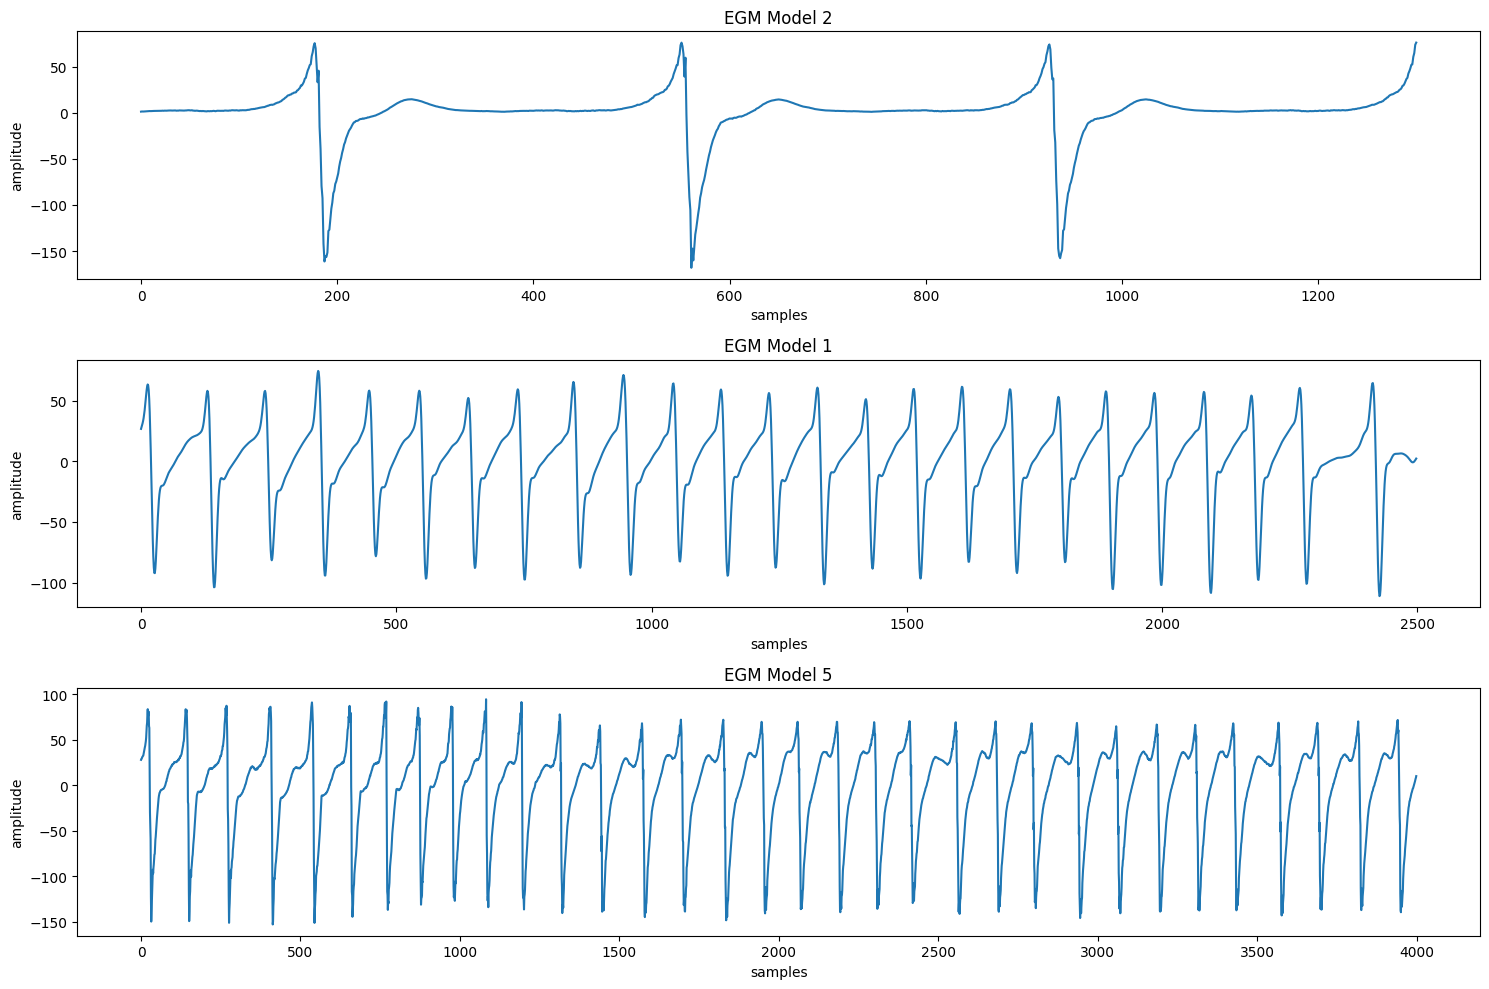

In [6]:
#plotting egms

import random

random_indices = random.sample(range(len(egms_values)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

for i, idx in enumerate(random_indices):
    axs[i].plot(egms_values[idx][10, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()


In [7]:

from tools import ECG_filtering  #NO ESTA ENCONTRANDO LA FUNCIÓN ASIQUE LA PEGO A MANO

def ECG_filtering(signal, fs, order = 2, f_low=3, f_high=60):
    """
    Frequency filtering of ECG-EGM.
    SR model: low-pass filtering, 4th-order Butterworth filter.
    FA models: bandpass filtering, 4th-order Butterworth filter.

    Parameters:
        signal (array): signal to process
        fs (int): sampling rate
        f_low (int-float): low cut-off frecuency (default=3Hz)
        f_high (int-float): high cut-off frecuency (default=30Hz)
        model (string): FA model to assess (default: SR)
    Returns:
        proc_ECG_EGM (array): filtered ECG-EGM
    """

    # Remove DC component
    sig_temp = remove_mean(signal)
    #sig_temp = signal

    # Bandpass filtering
    b, a = sigproc.butter(
        order, [f_low / round((fs / 2)), f_high / round((fs / 2))], btype="bandpass"
    )

    proc_ECG_EGM = np.zeros(sig_temp.shape)
    if sig_temp.ndim ==3:
        for i in range(sig_temp.shape[1]):  
            for j in range(sig_temp.shape[2]):  
                #for index in range(sig_temp.shape[0]):
                proc_ECG_EGM[:, i, j] = sigproc.filtfilt(b, a, sig_temp[:, i, j])
    else: 
        for index in range(0, sig_temp.shape[0]):
            proc_ECG_EGM[index, :] = sigproc.filtfilt(b, a, sig_temp[index, :])

    return proc_ECG_EGM


egms_filtered_norm = []

for i in range(len(egms_values)):
    
    #ECG FILTERING
    egms = egms_values[i]
    print(egms.shape)
    egms_filt = ECG_filtering(egms.T, 500)
    


    #NORMLIZE EGMS
    high = 1
    low = -1

    mins = np.min(egms_filt, axis=0)
    maxs = np.max(egms_filt, axis=0)
    rng = maxs - mins

    norm_egms = high - (((high - low) * (maxs - egms_filt)) / rng)
    
    norm_egms = norm_egms.T #para que queden otra vez (2048 x samples of time)
    egms_filtered_norm.append(norm_egms)



(2048, 1500)
(2048, 2499)
(2048, 1301)
(2048, 1500)
(2048, 4000)
(2048, 4000)
(2048, 2000)
(2048, 2000)
(2048, 2001)
(2048, 2499)
(2048, 2499)
(2048, 4501)


In [8]:
print(len(egms_filtered_norm))
print(egms_filtered_norm[0].shape)

#PREGUNTAR A OSCAR SI DEBERÍA ACOTAR TODOS A UN TIEMPO, POR EJEMPLO 1000 UNIDADES DE TIEMPO --> si hago esto puedo convertirlos en np arrays


12
(2048, 1500)


In [9]:
print(egms_filtered_norm[0][0, :].shape)

(1500,)


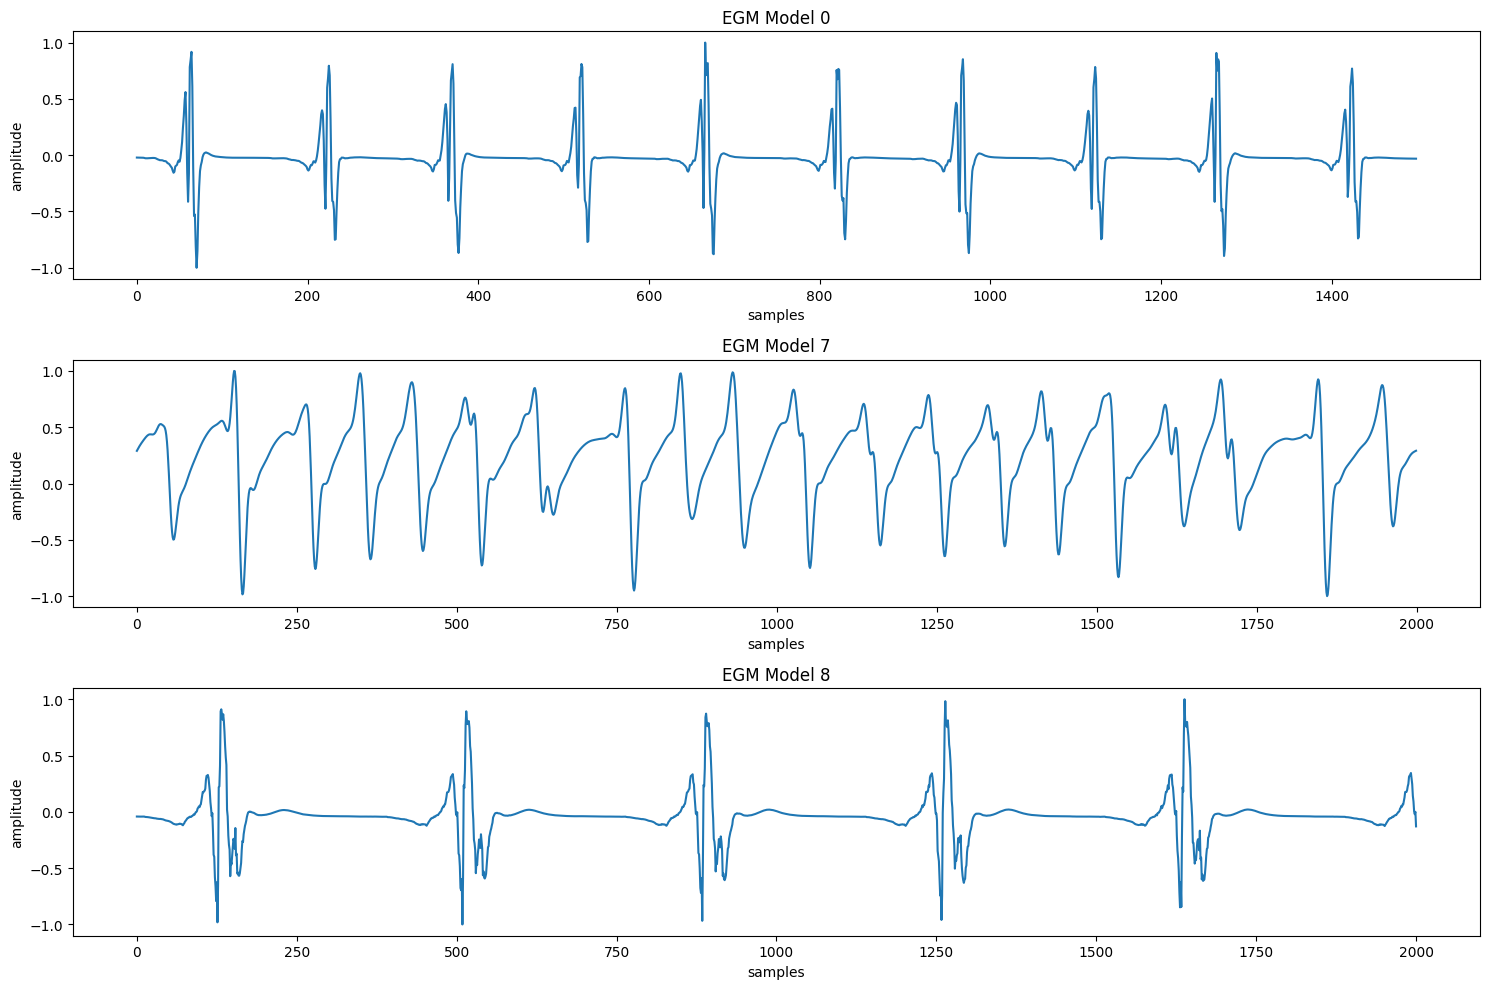

In [10]:
#plotting egms filtered and normalized

random_ind = random.sample(range(len(egms_filtered_norm)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

for i, idx in enumerate(random_ind):
    axs[i].plot(egms_filtered_norm[idx][10, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()

In [11]:
transfer_matrices = load_transfer(ten_leads=False, bsps_set=False)

In [12]:

print(transfer_matrices[0][1].shape) #--> 64 electrodes 
print(transfer_matrices[0][0].shape)
print(transfer_matrices[1][0].shape)
print(transfer_matrices[1][1].shape) 

(64, 1)
(3610, 2048)
(3970, 2048)
(64, 1)


In [13]:
#COMPUTING THE FORWARD PROBLEM

# y = A*x --> y: bsps, A: transfer matrix, x: egms
# A =  (3018x2048) --> 3018 nodos en el torso de los 64 electrodos 
#                  --> 2048 electrodos en la auricula 
# x = (2048x1000)  --> 1000 samples of time
# y = (3018x1000)  

A = transfer_matrices[0]

print(A)
print(A[1].shape) #--> matriz de transferencia

bsps_all_models = []
for i in range(len(egms_filtered_norm)):

    y_f = forward_problem(egms_filtered_norm[i], A[0]) # bsps
    bsps_all_models.append(y_f)


(array([[ 7.69965054e-05,  7.34290114e-05,  5.55983500e-05, ...,
        -4.30014225e-04,  3.20904568e-03,  2.03465098e-03],
       [-1.46424028e-04, -1.47995566e-04, -6.64696334e-05, ...,
         6.82507351e-04, -1.64109737e-03, -7.97225589e-04],
       [-1.17874811e-04, -1.11635205e-04, -5.44792074e-05, ...,
        -2.10877594e-04, -1.42770170e-03, -1.17830147e-03],
       ...,
       [-4.31684863e-05, -3.11358531e-05, -1.69536380e-05, ...,
        -1.81270509e-04, -4.25855593e-05, -2.64389011e-04],
       [-9.15845321e-05, -8.35069368e-05, -4.04402041e-05, ...,
        -4.26394139e-04, -9.76937571e-04, -9.75087733e-04],
       [-5.75701441e-05, -4.84485410e-05, -3.20869635e-05, ...,
         2.06745799e-04, -1.04379968e-03, -9.80077168e-04]]), array([[ 552],
       [3422],
       [2994],
       [  46],
       [ 971],
       [2982],
       [ 520],
       [ 522],
       [3502],
       [3188],
       [ 674],
       [ 472],
       [2694],
       [2641],
       [  18],
       [  40],
 

In [14]:
print(bsps_all_models[1].shape)

(3610, 2499)


(2000,)
(4000,)
(1500,)


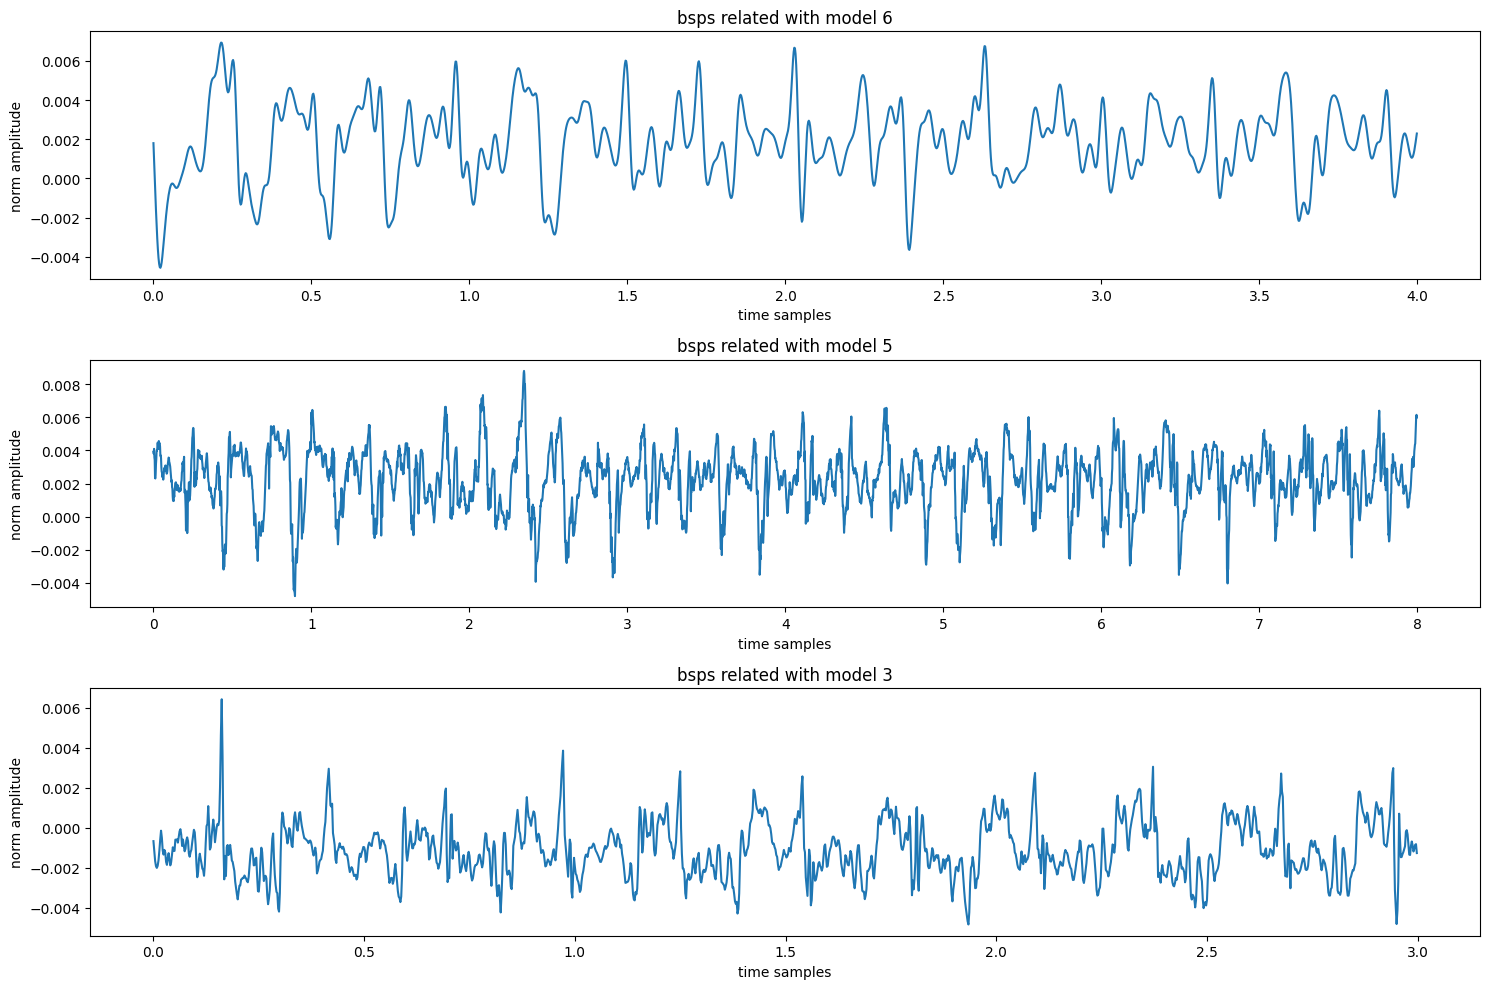

In [15]:
#plotting bsps

random_ind = random.sample(range(len(bsps_all_models)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

for i, idx in enumerate(random_ind):

    t = np.arange(len(bsps_all_models[idx][0, :]))/500
    print(t.shape)
    axs[i].plot(t, bsps_all_models[idx][0, :]) 
    axs[i].set_title(f'bsps related with model {idx}')  
    axs[i].set_xlabel('time samples')
    axs[i].set_ylabel('norm amplitude')

plt.tight_layout()
plt.show()

In [16]:
#nos quedamos con 64 nodos para los bsps como chaqueta
bsps_64_all_models = []
for i in range(len(bsps_all_models)):

    bsps_64 = bsps_all_models[i][A[1].ravel(),:]
    print(bsps_64.shape)
    bsps_64_all_models.append(bsps_64)


(64, 1500)
(64, 2499)
(64, 1301)
(64, 1500)
(64, 4000)
(64, 4000)
(64, 2000)
(64, 2000)
(64, 2001)
(64, 2499)
(64, 2499)
(64, 4501)


In [17]:
print(len(bsps_64_all_models))
print(bsps_64_all_models[0][0,:].shape)
bsps_ex_signal = bsps_64_all_models[0][0,:].reshape(1,-1)
print(bsps_ex_signal.shape)
bsps_ex_signal[0].shape

12
(1500,)
(1, 1500)


(1500,)

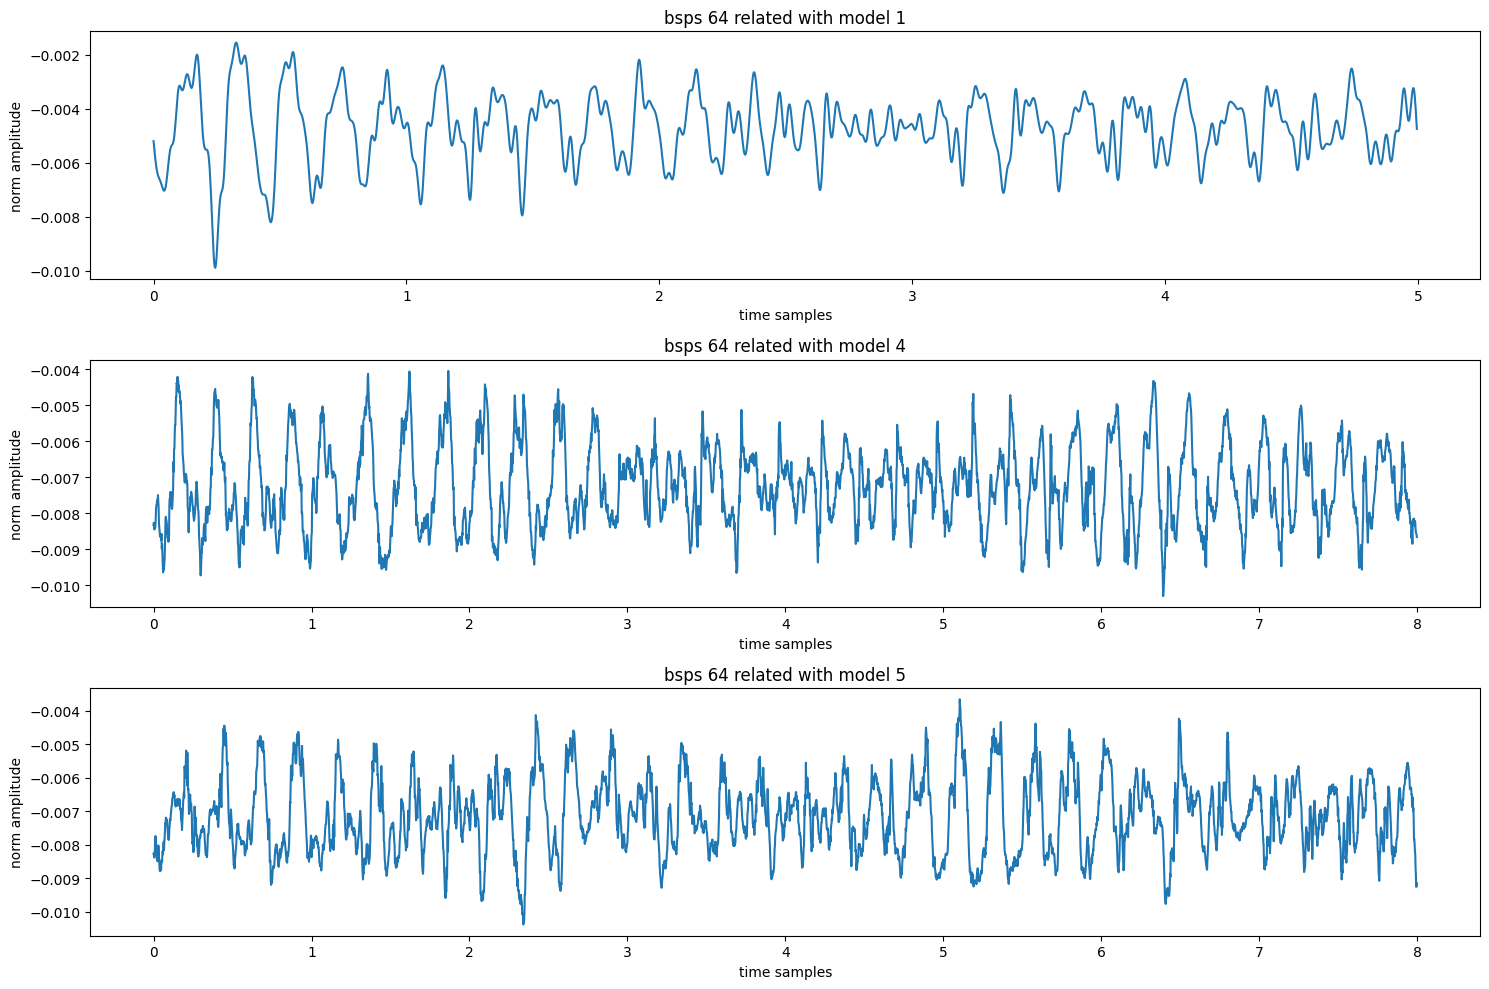

In [18]:
#plotting bsps

random_ind = random.sample(range(len(bsps_64_all_models)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

for i, idx in enumerate(random_ind):

    t = np.arange(len(bsps_64_all_models[idx][0, :]))/500
    axs[i].plot(t, bsps_64_all_models[idx][0, :]) 
    axs[i].set_title(f'bsps 64 related with model {idx}')  
    axs[i].set_xlabel('time samples')
    axs[i].set_ylabel('norm amplitude')

plt.tight_layout()
plt.show()

SACO SPECTROGRAM DE FOURIER

In [19]:
print(len(bsps_64_all_models))

print(bsps_64_all_models[0][0,:].shape)  # primer nodo (de 64) del primer modelo (de 12)

bsps_ex_signal_all_models = []
for i in range(len(bsps_64_all_models)):

    bsps_ex_signal = bsps_64_all_models[i][0,:].reshape(1,-1)  # si pongo [1,:] me quedo con el segundo nodo y asi sucesivamente
    print(bsps_ex_signal.shape)
    bsps_ex_signal[0].shape
    bsps_ex_signal_all_models.append(bsps_ex_signal)

12
(1500,)
(1, 1500)
(1, 2499)
(1, 1301)
(1, 1500)
(1, 4000)
(1, 4000)
(1, 2000)
(1, 2000)
(1, 2001)
(1, 2499)
(1, 2499)
(1, 4501)


PERIODOGRAMA DE WELCH --> Para ver los picos de energia

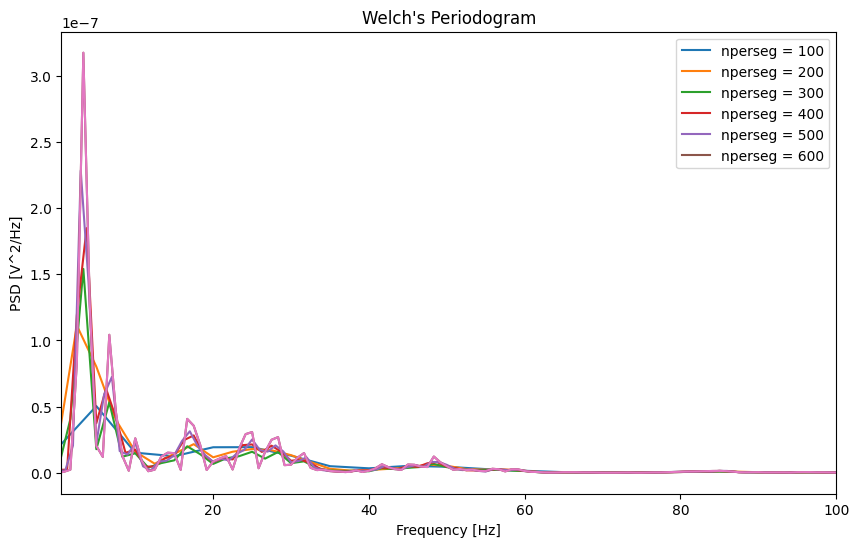

In [20]:
#ploteamos para un nodo y un solo modelo el periodograma de welch con diferentes nperseg para encontrar cual nos da mejor resultado

from scipy.signal import welch
plt.figure(figsize=(10, 6))

nperseg = [100, 200, 300, 400, 500, 600]

for i in range(len(nperseg)):
    freq, psd = welch(bsps_ex_signal_all_models[0][0], fs=500, nperseg=nperseg[i], noverlap=nperseg[i] // 2)
    #plt.figure(figsize=(10, 6))
    plt.plot(freq, psd, label=f'nperseg = {nperseg[i]}')   # --> vemos que sale mejor con nperseg = 600


plt.plot(freq, psd)
plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 100)  # --> acotamos el eje x para ver mejor porque cardiac signal estan en un rango menor que 100 hz
plt.ylabel("PSD [V^2/Hz]")
plt.legend()
plt.show()

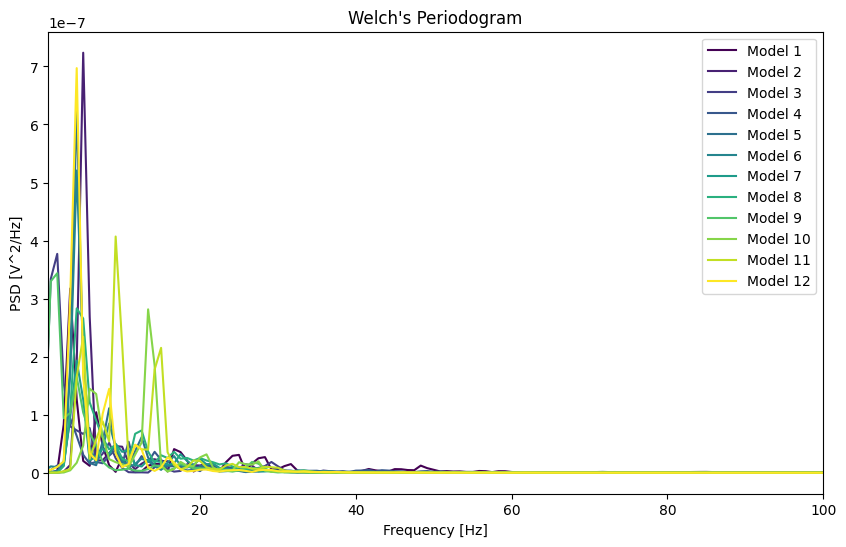

In [21]:


plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(bsps_ex_signal_all_models)))  # Generar una lista de colores

nperseg=600
for i in range(len(bsps_ex_signal_all_models)):

    freq, psd = welch(bsps_ex_signal_all_models[i][0], fs=500, nperseg=nperseg, noverlap=nperseg // 2)

    plt.plot(freq, psd, label=f'Model {i+1}', color=colors[i])

plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 100) 
plt.ylabel("PSD [V^2/Hz]")
plt.legend()  
   
plt.show()


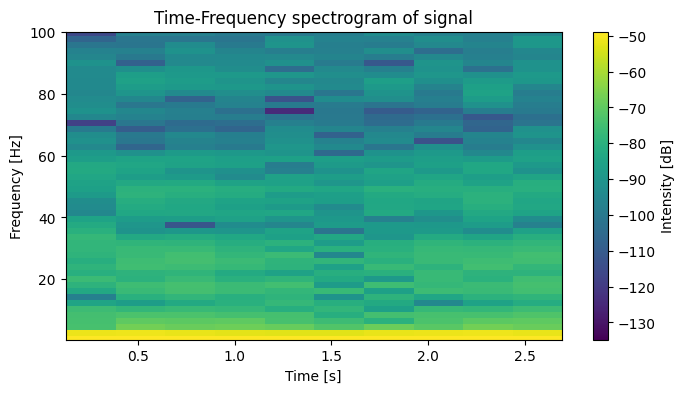

In [22]:
#aqui estoy haciendo el spectrogram para un solo nodo y un solo modelo

# como vemos en el periodograma anterior, la intensidad mas alta se obtiene en esas frecuencias en el rango 0-10 hz aprox
# linea amarilla mucho mas intensa que las demas que se mantiene en el tiempo porque la señal es periodica

#como es periódica tenemos los mismos componentes frecuenciales en toda la longitud temporal de la señal
#los 5 Hz (lo que sale amarillo) es una componente frecuencial constante, que es el ritmo al que salen los latidos má o menos

plt.figure(figsize=(8, 4))
plt.specgram(bsps_64_all_models[0][0,:], Fs=500)
plt.title("Time-Frequency spectrogram of signal")
plt.xlabel("Time [s]")
plt.ylim(0.5, 100)
plt.ylabel("Frequency [Hz]")
plt.colorbar(label='Intensity [dB]')
plt.show()

12
(4000,)


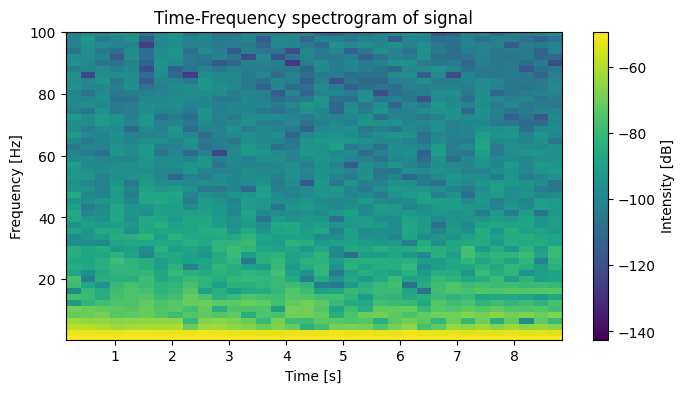

In [24]:
#sprecrograma para todos los modelos para un solo nodo


print(len(bsps_ex_signal_all_models))
print(bsps_ex_signal_all_models[4][0,:].shape)

plt.figure(figsize=(8,4))
for i in range(len(bsps_ex_signal_all_models)):
    plt.specgram(bsps_64_all_models[i][0,:], Fs=500)
plt.title("Time-Frequency spectrogram of signal")
plt.xlabel("Time [s]")
plt.ylim(0.5, 100)
plt.ylabel("Frequency [Hz]")
plt.colorbar(label='Intensity [dB]')
plt.show()

Uso un bsps_64 rel con el modelo 0 para aplicarle wavelet scattering, sacar los coefficientes de diferente orden (0, 1 o 2) y dibujar esos coefficientes dependiendo de su orden. 

Que uso tienen y que representan los coeffs de distinto orden: 

* 0: Coeficiente de orden cero (energía total de la señal).
* 1: Coeficiente de primer orden (captura variaciones locales).
* 2: Coeficiente de segundo orden (captura interacciones entre diferentes escalas).

In [42]:
from kymatio import Scattering1D

signal_ex = bsps_64_all_models[0][0, :]
T = len(signal_ex)

scattering = Scattering1D(J=6, shape=T, Q=8) #calculate wavelet scattering coeffs

# Perform the scattering transform
Sx = scattering(signal_ex)
meta = scattering.meta()

# Metadata
print("meta keys", meta.keys())  

# Explorar los órdenes de los coeficientes
print('order of coeffs', meta['order'])  # coeff order

order_0_coeffs = Sx[meta['order'] == 0]  # coeffs order 0
print("Coeffs order 0:", order_0_coeffs.shape)

order_1_coeffs = Sx[meta['order'] == 1] # coeffs order 1
print("Coeffs order 1:", order_1_coeffs.shape)

order_2_coeffs = Sx[meta['order'] == 2] # coeffs order 2
print("Coeffs order 2:", order_2_coeffs.shape)

#------------------------------------------------------------------------------------------------------
#no entiendo bien que es 23 en los tamaños de los coeficientes
print(meta['xi']) # Frecuencia central del filtro wavelet utilizado para calcular el coeficiente. Representa la frecuencia a la que el filtro wavelet es más sensible.

print('SIGMA VAL', meta['sigma']) # 

meta keys dict_keys(['order', 'xi', 'sigma', 'j', 'n', 'key'])
order of coeffs [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Coeffs order 0: (1, 23)
Coeffs order 1: (38, 23)
Coeffs order 2: (87, 23)
[[       nan        nan]
 [0.43538087        nan]
 [0.39924602        nan]
 [0.36611021        nan]
 [0.33572454        nan]
 [0.30786076        nan]
 [0.28230957        nan]
 [0.25887901        nan]
 [0.2373931         nan]
 [0.21769043        nan]
 [0.19962301        nan]
 [0.18305511        nan]
 [0.16786227        nan]
 [0.15393038        nan]
 [0.14115478        nan]
 [0.12943951        nan]
 [0.11869655        nan]
 [0.10884522        nan]
 [0.0998115         nan]
 [0.09152755        nan]
 [0.08393114        nan]
 [0.07696519        nan]
 [0.07057739        nan]
 [0.06471975   

#### 
#### **INFO DE LOS KEYS QUE SALEN EN LA METADATA:**

* order: Indica el orden del coeficiente de dispersión. Puede ser 0, 1 o 2, donde:
- 0: Coeficiente de orden cero (energía total de la señal).
- 1: Coeficiente de primer orden (captura variaciones locales).
- 2: Coeficiente de segundo orden (captura interacciones entre diferentes escalas).

* xi: Frecuencia central del filtro wavelet utilizado para calcular el coeficiente. Representa la frecuencia a la que el filtro wavelet es más sensible.

* sigma: Ancho del filtro wavelet en el dominio de la frecuencia. Indica la selectividad en frecuencia del filtro.

* j: Escala del filtro wavelet. Representa la dilatación del filtro wavelet y está relacionada con la resolución temporal y frecuencial.

* n: Índice del filtro wavelet dentro de una escala específica. Se utiliza para diferenciar entre diferentes filtros dentro de la misma escala.

* key: Clave única que identifica el coeficiente de dispersión. Puede ser utilizada para acceder a los coeficientes específicos en el conjunto de resultados.

23
only 1 coeff of order 0


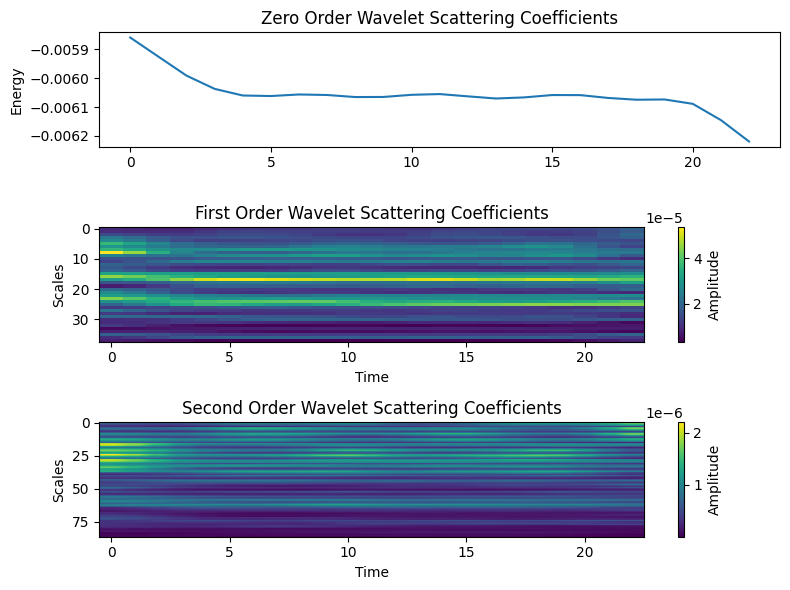

In [27]:
# PLOTTING SCATTERING COEFFS DEPENDING ON THE ORDER

plt.figure(figsize=(8, 6))

# Coeffs order 0
plt.subplot(3, 1, 1)
print(len(order_0_coeffs[0]))
#plt.plot(order_0_coeffs.T)

if len(order_0_coeffs) > 1:
    print("more than 1 coeff", len(order_0_coeffs))
    plt.plot(order_0_coeffs[0])
    

else:
    print("only 1 coeff of order 0")
    plt.plot(order_0_coeffs[0])

plt.title('Zero Order Wavelet Scattering Coefficients')
plt.ylabel('Energy')


# Coeffs order 1
plt.subplot(3, 1, 2)
plt.imshow(order_1_coeffs, aspect='auto')
plt.colorbar(label='Amplitude')
plt.title('First Order Wavelet Scattering Coefficients')
plt.xlabel('Time')
plt.ylabel('Scales')

# Coeffs order 2
plt.subplot(3, 1, 3)
plt.imshow(order_2_coeffs, aspect='auto')
plt.colorbar(label='Amplitude')
plt.title('Second Order Wavelet Scattering Coefficients')
plt.xlabel('Time')
plt.ylabel('Scales')

plt.tight_layout()
plt.show()

1500
(76, 47)


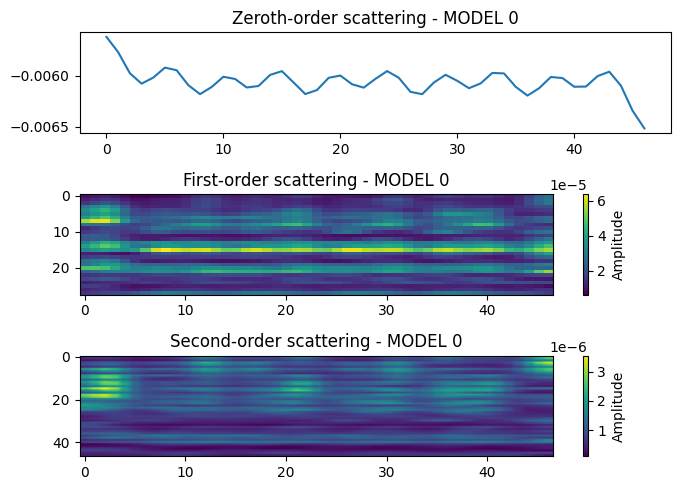

2499
(76, 79)


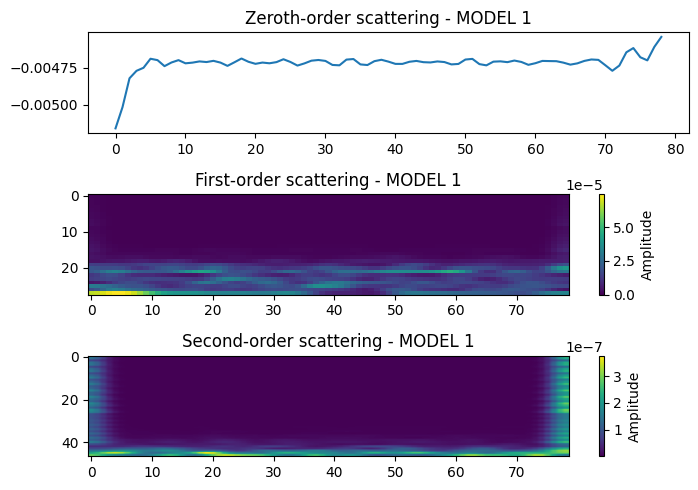

1301
(76, 41)


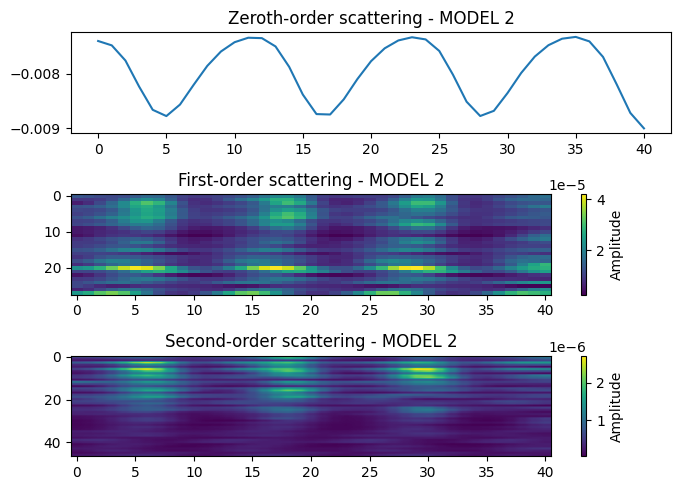

1500
(76, 47)


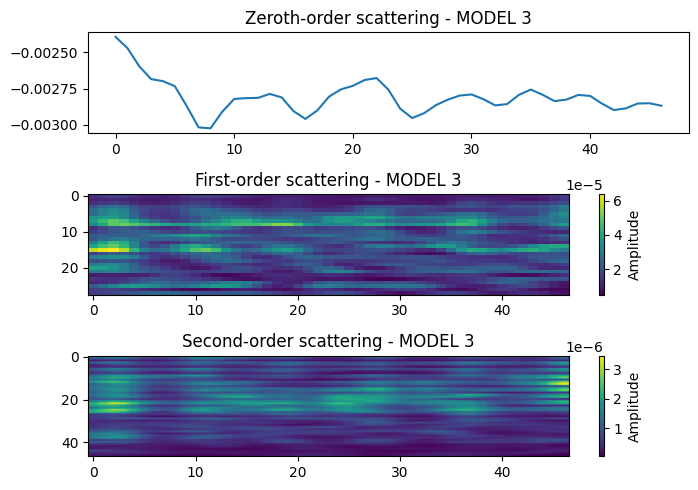

4000
(76, 125)


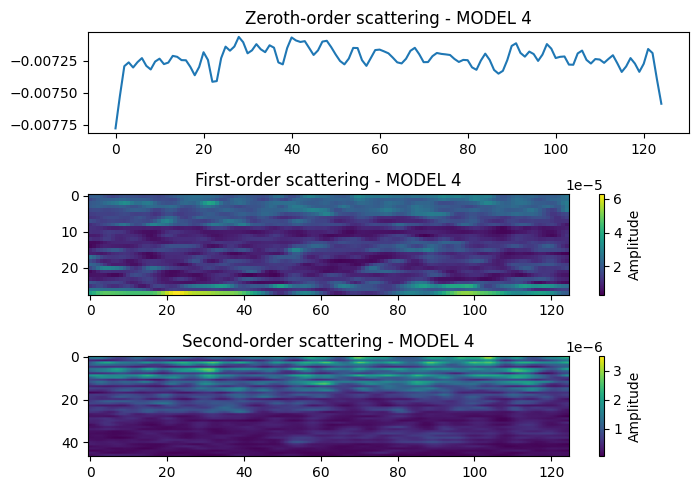

4000
(76, 125)


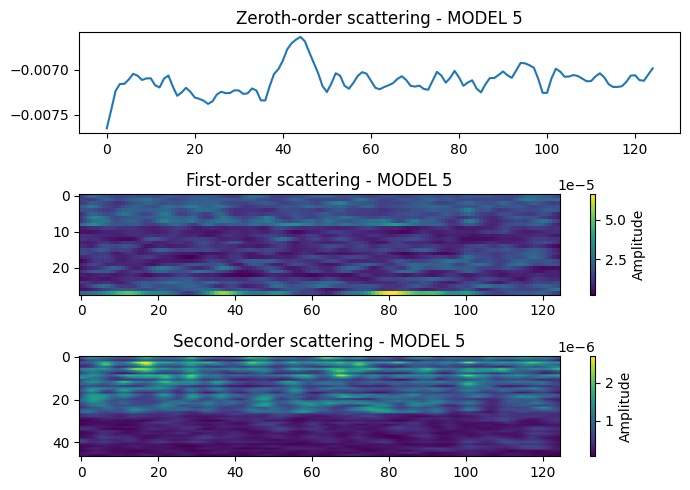

2000
(76, 63)


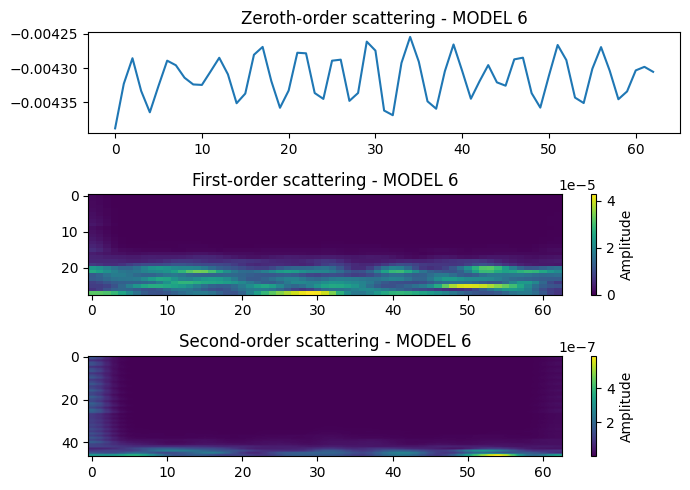

2000
(76, 63)


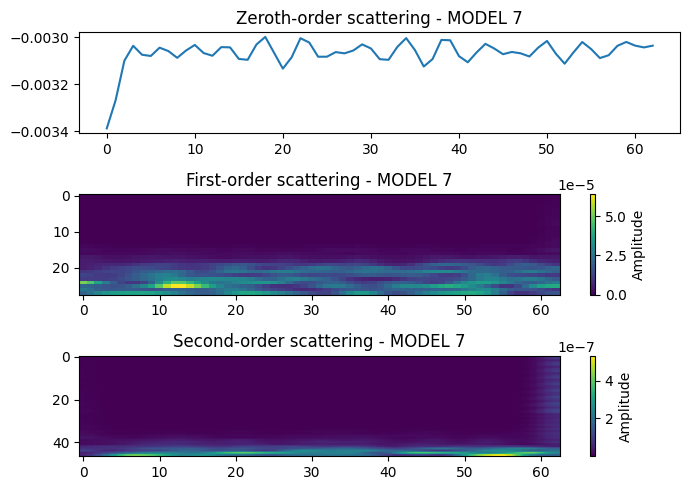

2001
(76, 63)


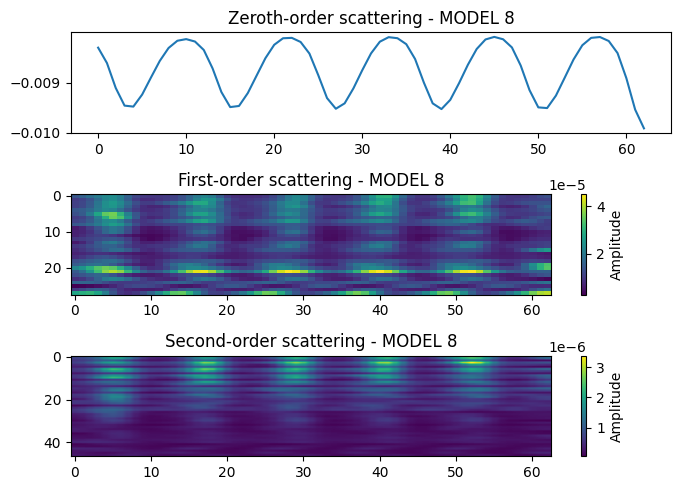

2499
(76, 79)


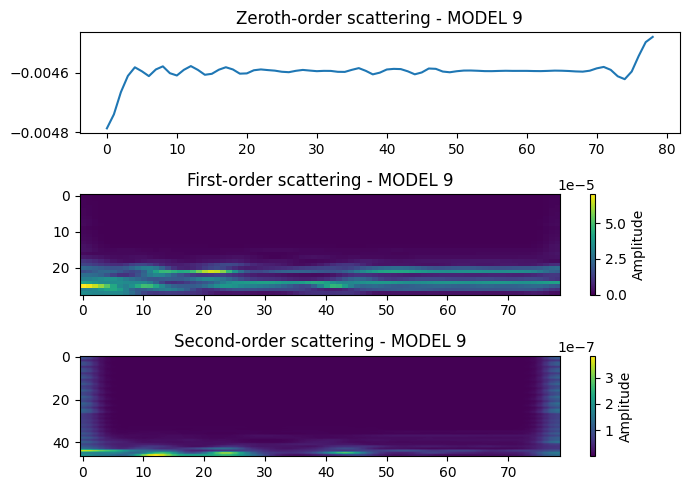

2499
(76, 79)


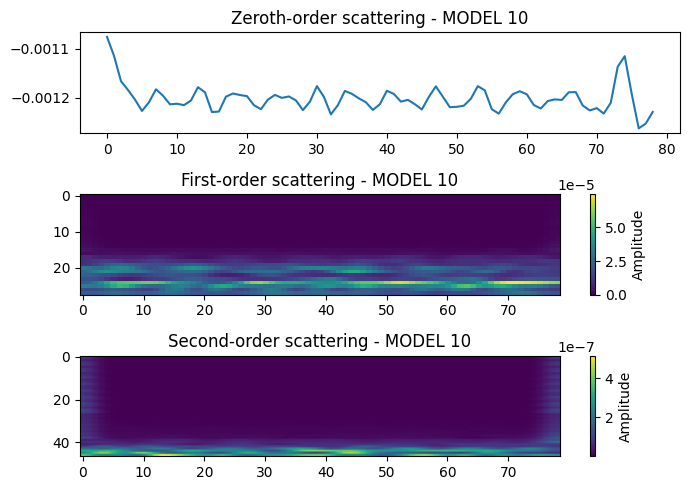

4501
(76, 141)


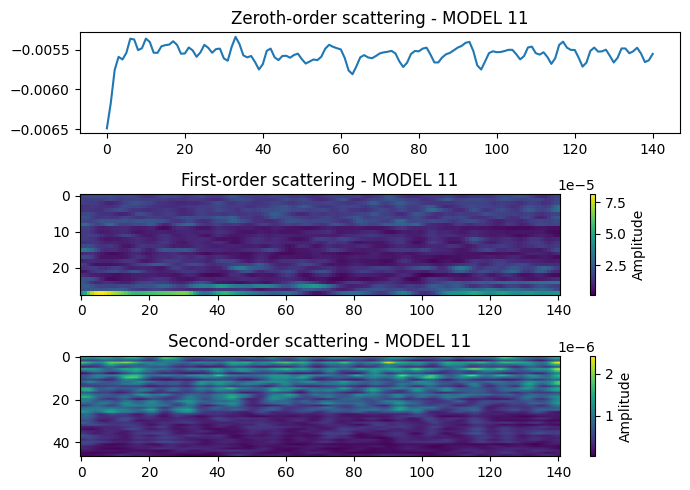

In [39]:
ws_coeffs_all_models = []
ws_coeffs_order0 = []
ws_coeffs_order1 = []
ws_coeffs_order2 = []


for i in range(len(bsps_64_all_models)):

    signal = bsps_64_all_models[i][0, :]
    T = len(signal)
    print(T)
    scattering = Scattering1D(J=5, shape=T, Q=7) #calculate wavelet scattering coeffs

    # Perform the scattering transform
    Sx = scattering(signal)
    meta = scattering.meta()
    print(Sx.shape)
    ws_coeffs_all_models.append(Sx)

    #print('order of coeffs', meta['order'])  # coeff order

    order_0 = np.where(meta['order'] == 0)  # coeffs order 0
    #print("Coeffs order 0:", order_0.shape)
    ws_coeffs_order0.append(order_0)

    order_1 = np.where(meta['order'] == 1) # coeffs order 1
    #print("Coeffs order 1:", order_1.shape)
    ws_coeffs_order1.append(order_1)

    order_2 = np.where(meta['order'] == 2) # coeffs order 2
    #print("Coeffs order 2:", order_2.shape)
    ws_coeffs_order2.append(order_2)

    plt.figure(figsize=(7, 5))
    plt.subplot(3, 1, 1)
    plt.plot(Sx[order_0][0])
    plt.title(f'Zeroth-order scattering - MODEL {i}')

    plt.subplot(3, 1, 2)
    plt.imshow(Sx[order_1], aspect='auto')
    plt.title(f'First-order scattering - MODEL {i}')
    plt.colorbar(label='Amplitude')

    plt.subplot(3, 1, 3)
    plt.imshow(Sx[order_2], aspect='auto')
    plt.title(f'Second-order scattering - MODEL {i}')
    plt.colorbar(label='Amplitude')
    
    plt.tight_layout()

    plt.show()

#### ¿Qué significan las ESCALAS (eje Y) en Wavelet Scattering?
En lugar de frecuencia (como en un espectrograma de Fourier), el eje Y en Wavelet Scattering representa las escalas de las wavelets.
Cada escala está asociada a un nivel de dilatación de la wavelet, lo que equivale a diferentes bandas de frecuencia:

Escalas bajas (índices pequeños en el eje Y) → Capturan detalles de alta frecuencia (cambios rápidos en la señal).
Escalas altas (índices grandes en el eje Y) → Capturan tendencias de baja frecuencia (estructuras globales más lentas).
Básicamente, es como si las escalas fueran "filtros" que descomponen la señal en diferentes niveles de detalle, análogos a bandas de frecuencia pero en términos de wavelets.

FILTROS DE FOURIER VS FILTROS WAVELET



Longitud nueva tras interpolación: 2048


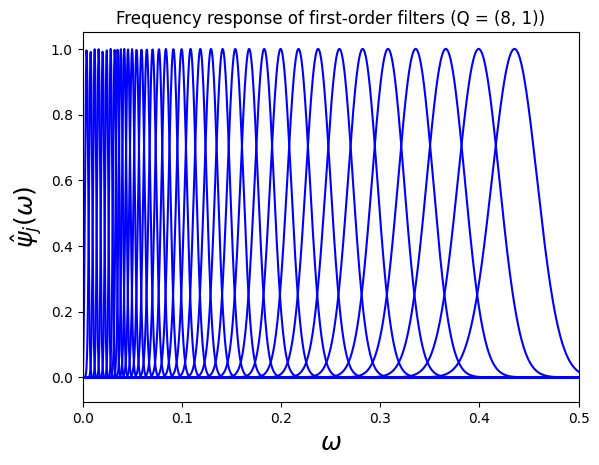

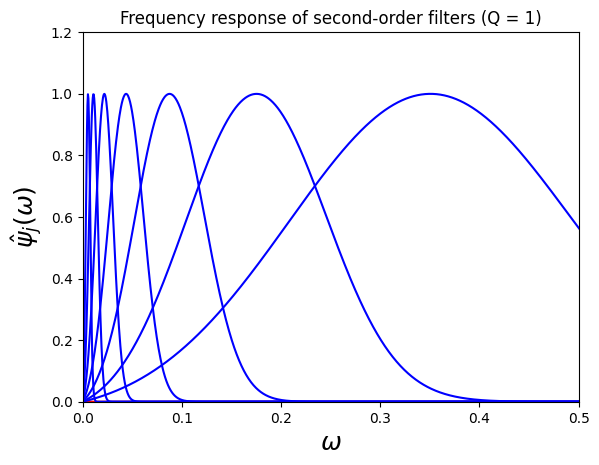

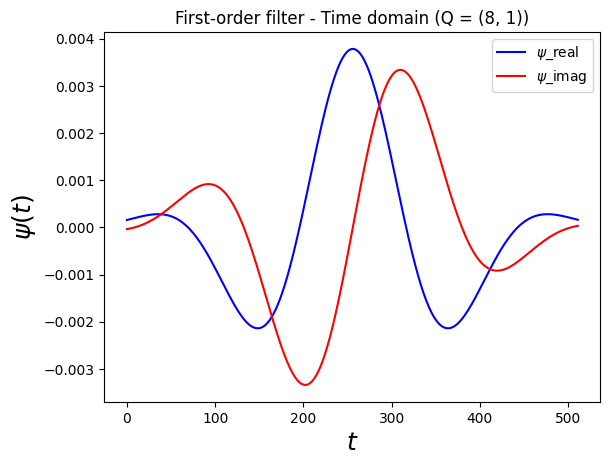

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from kymatio import Scattering1D
from kymatio.scattering1d.filter_bank import scattering_filter_factory

from scipy.signal import resample
signal = bsps_64_all_models[0][0, :]

new_length = 2048  # O puedes probar con 1024
resampled_signal = resample(signal, new_length)

print(f"Longitud nueva tras interpolación: {len(resampled_signal)}")

fs = 500

J = 6
Q = (8, 1)
T = len(resampled_signal)
phi_f, psi1_f, psi2_f = scattering_filter_factory(T, J, Q, T)

#Plot the frequency response of the filters
plt.figure()
plt.rcParams.update({"text.usetex": False})
plt.plot(np.arange(T)/T, phi_f['levels'][0], 'r')

for psi_f in psi1_f:
    plt.plot(np.arange(T)/T, psi_f['levels'][0], 'b')

#plt.xlim(0, 0.5)

plt.xlabel(r'$\omega$', fontsize=18)
plt.ylabel(r'$\hat\psi_j(\omega)$', fontsize=18)
plt.title('Frequency response of first-order filters (Q = {})'.format(Q),
          fontsize=12)

# same plot for the second-order filters. 
# Note that since here Q = 1, we obtain wavelets that have higher frequency bandwidth.

plt.figure()
plt.rcParams.update({"text.usetex": False})
plt.plot(np.arange(T)/T, phi_f['levels'][0], 'r')
for psi_f in psi2_f:
    plt.plot(np.arange(T)/T, psi_f['levels'][0], 'b')
#plt.xlim(0, 0.5)
plt.ylim(0, 1.2)
plt.xlabel(r'$\omega$', fontsize=18)
plt.ylabel(r'$\hat\psi_j(\omega)$', fontsize=18)
plt.title('Frequency response of second-order filters (Q = 1)', fontsize=12)


# Plot the filter in time domain
plt.figure()
plt.rcParams.update({"text.usetex": False})

psi_time = np.fft.ifft(psi1_f[-1]['levels'][0])
psi_real = np.real(psi_time)
psi_imag = np.imag(psi_time)
plt.plot(np.concatenate((psi_real[-2**8:],psi_real[:2**8])),'b')
plt.plot(np.concatenate((psi_imag[-2**8:],psi_imag[:2**8])),'r')


plt.xlabel(r'$t$', fontsize=18)
plt.ylabel(r'$\psi(t)$', fontsize=18)
plt.title('First-order filter - Time domain (Q = {})'.format(Q), fontsize=12)
plt.legend(["$\psi$_real","$\psi$_imag"])

plt.show()

In [21]:
# We need a small constant to add to the scattering coefficients before
# computing the logarithm. This prevents very large values when the scattering
# coefficients are very close to zero.
log_eps = 1e-6

# puede servir, web kymatio ex https://github.com/kymatio/kymatio/blob/main/examples/1d/classif_keras.py 

In [20]:
# To increase discriminability, we take the logarithm of the scattering
# coefficients (after adding a small constant to make sure nothing blows up
# when scattering coefficients are close to zero). This is known as the
# log-scattering transform.

#x = layers.Lambda(lambda x: tf.math.log(tf.abs(x) + log_eps))(x)

#https://www.kymat.io/gallery_1d/plot_synthetic.html 

NameError: name 'x' is not defined